In [22]:
import wandb
import pandas as pd
from datetime import datetime, timezone

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
project_path = "tidiane/patch_icl_eval"
timestamp_str = "2026-03-21T00:00:00Z"
dataset = "medsegbench"

# Filter options (applied before computing dice)
EXCLUDE_VERTEBRAE = False  # Set to True to exclude vertebrae from analysis
EXCLUDE_RIBS = False       # Set to True to exclude ribs from analysis
EXCLUDE_CUSTOM = []        # Add custom label patterns to exclude, e.g. ['kidney_cyst']

print(f"Dataset: {dataset}")
print(f"Filters: vertebrae={EXCLUDE_VERTEBRAE}, ribs={EXCLUDE_RIBS}, custom={EXCLUDE_CUSTOM}")

# Fetch runs
run_filters = {
    "$and": [
        {"created_at": {"$gt": timestamp_str}},
        {"config.base_dataset": dataset},
    ]
}

filtered_runs = api.runs(
    path=project_path,
    filters=run_filters
)

runs_data = {}

# Iterate through runs and extract metrics + per-case dice
for run in filtered_runs:
    print(f"Processing run: {run.name} (ID: {run.id})")
    
    try:
        # FIX: Reload full run data to get config (filtered query doesn't populate it)
        full_run = api.run(f"{project_path}/runs/{run.id}")
        config = full_run.config
        print(f"  config: {config}")
        
        method = config.get("method")
        input_size = config.get("preprocessing", {}).get("image_size", {})
        context_size_config = config.get("context_size")
        
        # Handle context_size being int or dict
        if isinstance(context_size_config, int):
            context_size = context_size_config
        else:
            context_size = context_size_config.get("val", {}) if context_size_config else None

        # Try to download per-case dice artifact
        per_case_df = None
        try:
            artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run.id}-per_case_dice:v0")
            artifact.download()
            table = artifact.get("per_case_dice.table.json")
            per_case_df = table.get_dataframe()
        except Exception as e:
            print(f"  -> No per_case_dice artifact: {e}")


        

        runs_data[run.name] = {
            "wandb_id": run.id,
            "config": config,
            "method": method,
            "input_size": input_size,
            "context_size": context_size,
            "gflops_per_sample": full_run.summary.get("gflops_per_sample"), 
            "val_final_dice": full_run.summary.get("val_final_dice"),
            "per_case_df": per_case_df,
        }
    except Exception as e:
        print(f"  -> Error processing run {run.name}: {e}")

print(f"\nSuccessfully downloaded data for {len(runs_data)} runs.")

Dataset: medsegbench
Filters: vertebrae=False, ribs=False, custom=[]
Processing run: rich-sound-402 (ID: l8huu3nw)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_co

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: fallen-violet-403 (ID: 3n69d943)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperatur

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: confused-bird-405 (ID: z3slm9er)
  config: {'model': {'patch_icl': {'loss': {'weights': {'default': {'target_patch': 1, 'context_patch': 0.5, 'target_aggreg': 1, 'context_aggreg': 0.5}, 'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'confidence': {'method': 'entropy', 'enabled': True, 'weighted_seg': False, 'boundary_width': 2, 'boundary_weight': 0, 'supervision_weight': 0}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperatur

...

Processing run: exalted-plant-407 (ID: gwyrmzg2)
  config: {'loss': {'aggreg_loss': {'args': None, 'type': 'softdice'}}, 'model': {'patch_icl': {'loss': {'weights': {'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperature': 0.1, 'spread_sigma_context': 4}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 128, 'num_patches': 20, 'sampling_method': 'continuous', 'num_cont

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: flowing-jazz-409 (ID: o6pza9bs)
  config: {'loss': {'aggreg_loss': {'args': None, 'type': 'softdice'}}, 'model': {'patch_icl': {'loss': {'weights': {'target_patch': 0, 'context_patch': 0, 'target_aggreg': 0, 'context_aggreg': 0, 'target_combined': 1}, 'patch_loss': {'args': None, 'type': 'softdiceFocal'}, 'aggreg_loss': {'args': None, 'type': 'softdiceFocal'}, 'level_weights': [0, 0, 0, 1]}, 'levels': [{'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 24, 'num_patches': 9, 'sampling_method': 'continuous', 'num_context_patches': 9, 'sampling_temperature': 0.1}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 64, 'num_patches': 20, 'sampling_method': 'continuous', 'num_context_patches': 20, 'spread_sigma_target': 4, 'sampling_temperature': 0.1, 'spread_sigma_context': 4}, {'stride': 8, 'pad_after': 0, 'pad_before': 0, 'patch_size': 8, 'resolution': 128, 'num_patches': 20, 'sampling_method': 'continuous', 'num_conte

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  



Successfully downloaded data for 6 runs.


In [23]:
print(method)

universeg


In [24]:
# Apply filters and recompute dice scores
excluded_patterns = []
if EXCLUDE_VERTEBRAE:
    excluded_patterns.append('vertebrae')
if EXCLUDE_RIBS:
    excluded_patterns.append('rib_')
excluded_patterns.extend(EXCLUDE_CUSTOM)

def compute_filtered_dice(per_case_df, excluded_patterns):
    """Compute mean dice after excluding specified label patterns."""
    if per_case_df is None:
        return None
    
    df = per_case_df.copy()
    
    if excluded_patterns:
        pattern = '|'.join(excluded_patterns)
        mask = df['label_id'].astype(str).str.contains(pattern, case=False, regex=True)
        n_excluded = mask.sum()
        df = df[~mask]
        
    return df['dice'].mean() if len(df) > 0 else None

# Recompute dice with filters applied
print("=" * 60)
if excluded_patterns:
    print(f"APPLYING FILTER: Excluding patterns {excluded_patterns}")
else:
    print("NO FILTER APPLIED")
print("=" * 60)

for run_name, data in runs_data.items():
    original_dice = data['val_final_dice']
    filtered_dice = compute_filtered_dice(data['per_case_df'], excluded_patterns)
    
    # Use filtered dice if available, otherwise fall back to original
    if filtered_dice is not None:
        data['filtered_dice'] = filtered_dice
        if excluded_patterns and original_dice is not None:
            diff = filtered_dice - original_dice
            print(f"{run_name}: {original_dice:.4f} -> {filtered_dice:.4f} (Δ={diff:+.4f})")
        else:
            data['filtered_dice'] = filtered_dice
    else:
        data['filtered_dice'] = original_dice  # Fallback to original if no per-case data

print(f"\nDice scores {'recomputed with filters' if excluded_patterns else 'unchanged'}.")

NO FILTER APPLIED

Dice scores unchanged.


In [25]:
# Display run summary
print("=" * 70)
print("RUN SUMMARY")
print("=" * 70)
print(f"\n{'Run':<25} {'Method':<12} {'Ctx':<5} {'Size':<5} {'GFLOPs':<10} {'Dice':<8}")
print("-" * 70)

for run_name, data in runs_data.items():
    print(data["method"], data["context_size"], data["input_size"], data["gflops_per_sample"], data["filtered_dice"])
    method = data['method'] or 'N/A'
    ctx = data['context_size'] if not isinstance(data['context_size'], list) else 'var'
    size = data['input_size'] or 'N/A'
    gflops = f"{data['gflops_per_sample']:.1f}" if data['gflops_per_sample'] else 'N/A'
    dice = f"{data['filtered_dice']:.4f}" if data['filtered_dice'] else 'N/A'
    
    #print(f"{run_name:<25} {method:<12} {ctx:<5} {size:<5} {gflops:<10} {dice:<8}")

RUN SUMMARY

Run                       Method       Ctx   Size  GFLOPs     Dice    
----------------------------------------------------------------------
patch_icl 3 256 100.3312511648 0.42958106452470635
patch_icl 3 512 295.5610004128 0.38658170362622896
patch_icl 3 128 51.5258854048 0.43449172446071044
universeg 3 128 34.334572544 0.5583852619217056
universeg 3 256 137.338290176 0.49988957360628494
universeg 3 512 549.353160704 0.44105150081865296


Method: patch_icl, ctx values:
  ctx=3, GFLOPs=51.526, Dice=0.4345
Method: universeg, ctx values:
  ctx=3, GFLOPs=34.335, Dice=0.5584


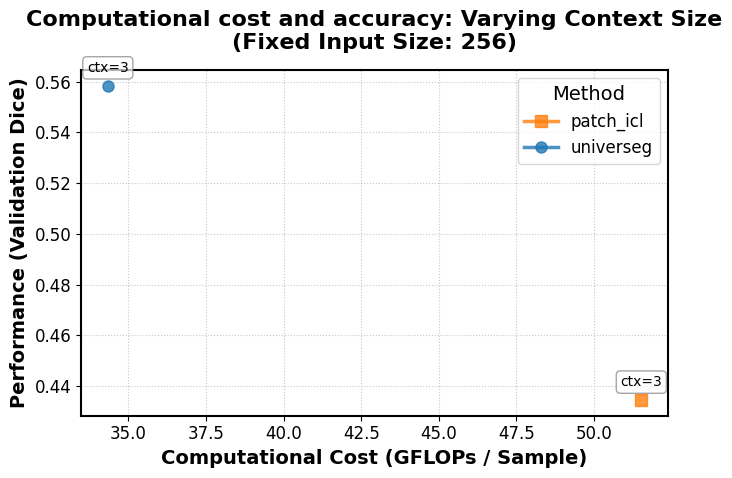

Method: patch_icl, in values:
  in=128, GFLOPs=51.526, Dice=0.4345
  in=256, GFLOPs=100.331, Dice=0.4296
  in=512, GFLOPs=295.561, Dice=0.3866
Method: universeg, in values:
  in=128, GFLOPs=34.335, Dice=0.5584
  in=256, GFLOPs=137.338, Dice=0.4999
  in=512, GFLOPs=549.353, Dice=0.4411


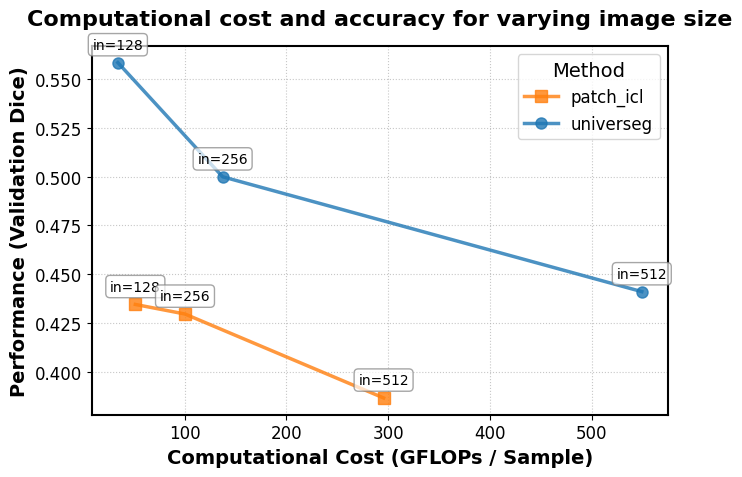

In [26]:
import matplotlib.pyplot as plt

# Set publication-ready style
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.autolayout': True,
    'axes.linewidth': 1.5,
})

# Convert runs_data to DataFrame (using filtered_dice)
df = pd.DataFrame.from_dict(runs_data, orient='index')

# Use filtered_dice for plotting
dice_col = 'filtered_dice'

def plot_pareto(df, vary_col, fixed_col, fixed_val, title, filename, label_prefix):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Filter for the specific experiment
    plot_df = df[df[fixed_col] == fixed_val].copy()
    
    # Remove rows with missing data
    plot_df = plot_df.dropna(subset=['gflops_per_sample', dice_col])
    
    if plot_df.empty:
        print(f"No data found for {fixed_col} == {fixed_val}. Skipping plot.")
        return

    methods = plot_df['method'].unique()
    colors = {'universeg': 'tab:blue', 'patch_icl': 'tab:orange'}
    markers = {'universeg': 'o', 'patch_icl': 's'}
    
    # Plot each method as its own line
    for method in methods:
        method_df = plot_df[plot_df['method'] == method].sort_values('gflops_per_sample')
        
        ax.plot(method_df['gflops_per_sample'], method_df[dice_col], 
                marker=markers.get(method, 'o'), color=colors.get(method, 'k'), 
                label=method, markersize=8, linewidth=2.5, alpha=0.8)
        
        # Annotate each data point
        for _, row in method_df.iterrows():
            ax.annotate(f"{label_prefix}={int(row[vary_col])}", 
                        (row['gflops_per_sample'], row[dice_col]),
                        textcoords="offset points", 
                        xytext=(0, 10),
                        ha='center', 
                        fontsize=10,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
        # Print plotted values
        print(f"Method: {method}, {label_prefix} values:")
        for _, row in method_df.iterrows():
            print(f"  {label_prefix}={int(row[vary_col])}, GFLOPs={row['gflops_per_sample']:.3f}, Dice={row[dice_col]:.4f}")

    # Add filter info to title if filtering is active
    filter_info = ""

    
    ax.set_xlabel('Computational Cost (GFLOPs / Sample)', fontweight='bold')
    ax.set_ylabel('Performance (Validation Dice)', fontweight='bold')
    ax.set_title(title + filter_info, pad=15, fontweight='bold')
    ax.legend(title="Method")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Plot for Varying Context Size (Fixing Input Size to 128)
plot_pareto(df, 
            vary_col='context_size', 
            fixed_col='input_size', 
            fixed_val=128, 
            title='Computational cost and accuracy: Varying Context Size\n(Fixed Input Size: 256)', 
            filename='pareto_context_size.pdf',
            label_prefix='ctx')

# Plot for Varying Input Size (Fixing Context Size to 3)
plot_pareto(df, 
            vary_col='input_size', 
            fixed_col='context_size', 
            fixed_val=3, 
            title='Computational cost and accuracy for varying image size', 
            filename='pareto_input_size.pdf',
            label_prefix='in')